In [ ]:
import sys
sys.path.insert(0, "D:\Internship\DTU Copenhagen (summer 2025)\PINNProof")  # change the path to your own path till PINNProof

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, 
                 D, P_m,
                 X_d_dash, X_q_dash,
                 X_d, X_q,
                 X_d_dash2, X_q_dash2,
                 H,
                 Rs, Re,
                 T_d_dash, T_q_dash,
                 T_d_dd, T_q_dd,
                 E_fd):
        """
        6th-order synchronous machine model whose state is:
         [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs]
        """
        super().__init__()
        # mechanical & electrical params
        self.D = D
        self.P_m = P_m
        self.omega_B = 2 * torch.pi * 50.0
        self.H = H

        # reactances
        self.X_d_dash   = X_d_dash
        self.X_q_dash   = X_q_dash
        self.X_d        = X_d
        self.X_q        = X_q
        self.X_d_dash2  = X_d_dash2
        self.X_q_dash2  = X_q_dash2

        # resistances
        self.Rs = Rs
        self.Re = Re

        # time constants
        self.T_d_dash = T_d_dash
        self.T_q_dash = T_q_dash
        self.T_d_dd   = T_d_dd
        self.T_q_dd   = T_q_dd

        # field voltage
        self.E_fd = E_fd

        # precompute stator-impedance inverse
        Z = torch.tensor([[self.Rs,        -self.X_q_dash],
                          [ self.X_d_dash,  self.Rs    ]],
                         dtype=torch.float32)
        self.register_buffer('Z_inv', torch.linalg.inv(Z))

    def forward(self, t, y):
        """
        y: tensor of shape (8,) = [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs]
        returns dy/dt of same shape
        """
        δ, ω, E_d_dash, E_q_dash, E_q_dd, E_d_dd, V_t, θ_vs = torch.unbind(y)

        # stator d/q voltages
        v_d = E_d_dash - V_t * torch.sin(δ - θ_vs)
        v_q = E_q_dash - V_t * torch.cos(δ - θ_vs)

        # currents
        I_d = self.Z_inv[0,0] * v_d + self.Z_inv[0,1] * v_q
        I_q = self.Z_inv[1,0] * v_d + self.Z_inv[1,1] * v_q

        # electrical power
        P_e = (E_d_dash * I_d
               + E_q_dash * I_q
               + (self.X_q_dash - self.X_d_dash) * I_d * I_q)

        # swing equations
        dδ_dt = ω
        dω_dt = (self.omega_B / (2*self.H)) * (self.P_m - P_e - self.D*ω)

        # transient emf dynamics (4th order)
        dE_d_dash = (1.0/self.T_q_dash) * (
            -E_d_dash + (self.X_q - self.X_q_dash)*I_q
        )
        dE_q_dash = (1.0/self.T_d_dash) * (
            -E_q_dash - (self.X_d - self.X_d_dash)*I_d + self.E_fd
        )

        # damper-winding (6th order)
        dE_q_dd = (1.0/self.T_d_dd) * (
            E_q_dash - E_q_dd + (self.X_d_dash - self.X_d_dash2)*I_d
        )
        dE_d_dd = (1.0/self.T_q_dd) * (
            E_d_dash - E_d_dd - (self.X_q_dash - self.X_q_dash2)*I_q
        )

        # V_t and θ_vs are exogenous => zero derivative
        dV_t    = torch.tensor(0.0, device=y.device)
        dθ_vs   = torch.tensor(0.0, device=y.device)

        return torch.stack([
            dδ_dt, dω_dt,
            dE_d_dash, dE_q_dash,
            dE_q_dd,   dE_d_dd,
            dV_t,      dθ_vs
        ])

    def interface(self, trajectory):
        """
        Given trajectory tensor shape (batch, time, 8):
         [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs],
        compute and return (I_D, I_Q) each of shape (batch, time).
        """
        δ   = trajectory[..., 0]
        E_d = trajectory[..., 2]
        E_q = trajectory[..., 3]
        V_t = trajectory[..., 6]
        θ_vs= trajectory[..., 7]

        # d/q voltages
        v_d = E_d - V_t * torch.sin(δ - θ_vs)
        v_q = E_q - V_t * torch.cos(δ - θ_vs)

        # currents
        I_d = self.Z_inv[0,0]*v_d + self.Z_inv[0,1]*v_q
        I_q = self.Z_inv[1,0]*v_d + self.Z_inv[1,1]*v_q

        # park transform to D/Q frame
        cosρ = torch.cos(δ - torch.pi/2)
        sinρ = torch.sin(δ - torch.pi/2)
        I_D =  I_d * cosρ - I_q * sinρ
        I_Q =  I_d * sinρ + I_q * cosρ

        return I_D, I_Q

D:\Internship\DTU Copenhagen (summer 2025)\PINNProof\src\solvers\ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


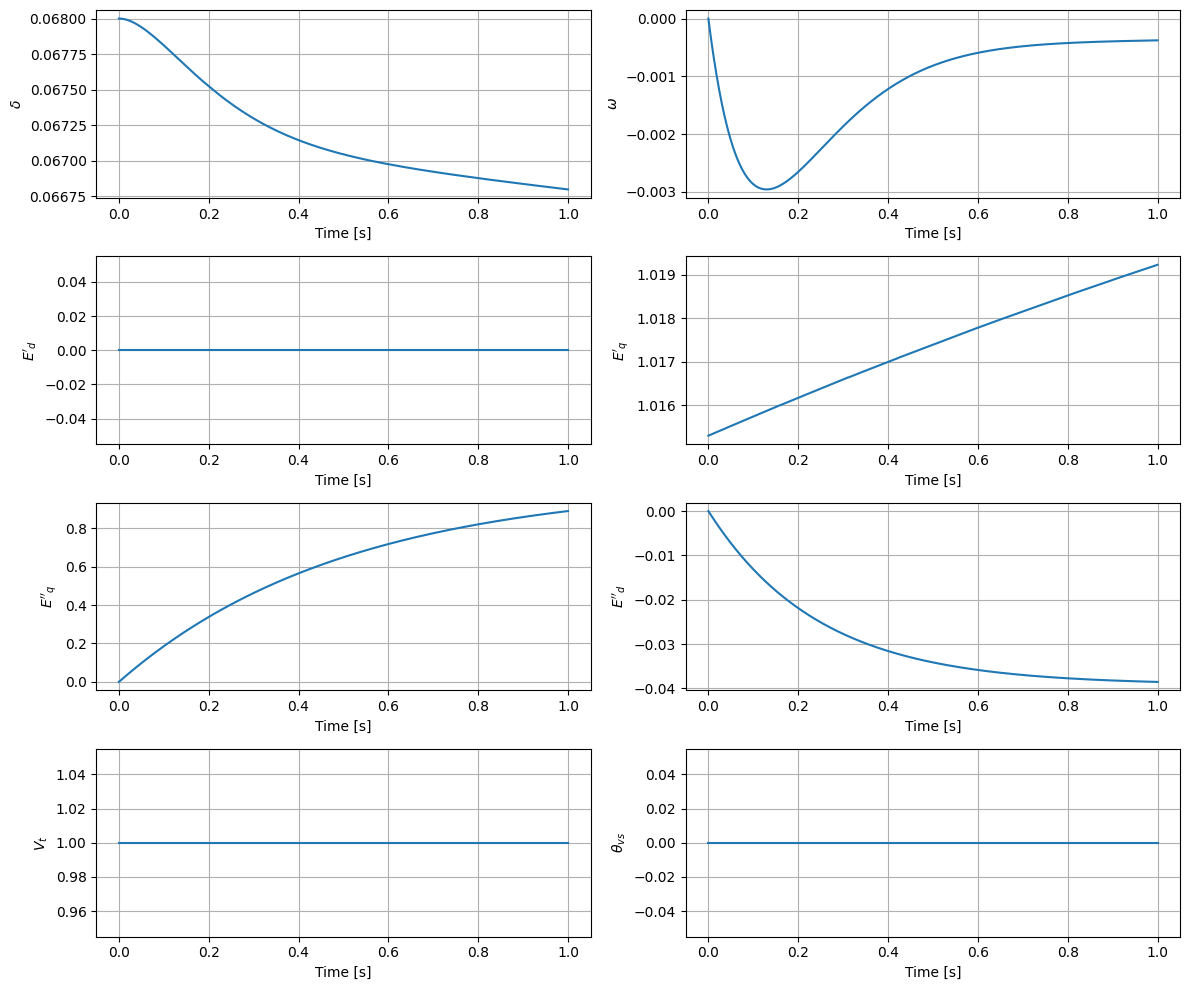

In [3]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from src.solvers.solver import Solver           # your base classes
from src.solvers.ODE_conventional import ODE_conventional

# 1) Time‐vector and constant Vs profile
t_final, num_points = 1.0, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)   # 1.0 pu
θs       = torch.zeros(num_points)  # 0 rad
# We'll embed Vs and θs directly into the state, so no extra stack needed here.

# 2) Machine parameters & instantiation
params = {
    'D'         : 2.364,
    'P_m'       : 0.71,
    'X_d_dash'  : 0.0608,
    'X_q_dash'  : 0.0969,
    'X_d'       : 0.146,
    'X_q'       : 0.0969,
    'X_d_dash2' : 0.03,
    'X_q_dash2' : 0.04,
    'H'         : 23.64,
    'Rs'        : 0.0,
    'Re'        : 0.0,
    'T_d_dash'  : 8.96,
    'T_q_dash'  : 0.31,
    'T_d_dd'    : 0.5,
    'T_q_dd'    : 0.25,
    'E_fd'      : 1.08
}
machine = SynchronousMachine(**params)

# 3) Wrap into your conventional ODE solver
#    forward: (t,y)->dy/dt, interface: (batch, time, 8)->(I_D,I_Q)
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Build the 8-dim initial state [δ₀, ω₀, E′d₀, E′q₀, E″q₀, E″d₀, V_s₀, θ_s₀]
δ0       = 0.0680
ω0       = 0.0
E_d0     = 0.0
E_q0     = 1.0153
E_q_dd0  = 0.0
E_d_dd0  = 0.0
V_s0     = Vs[0].item()   # 1.0
θ_s0     = θs[0].item()   # 0.0
x0 = torch.tensor([δ0, ω0, E_d0, E_q0, E_q_dd0, E_d_dd0, V_s0, θ_s0],
                  dtype=torch.float32)

# 5) Solve!
t_sol, sol = solver.solve(x0, t_final, num_points)
# sol has shape (num_points, 8)

# 6) Extract rotor states
delta  = sol[:, 0]
omega  = sol[:, 1]
E_d    = sol[:, 2]
E_q    = sol[:, 3]

#import matplotlib.pyplot as plt

# assume t_sol (num_points,) and sol (num_points, 8) are from your solver
# sol[:,i] corresponds to:
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_q$",
    r"$E''_d$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i in range(8):
    axs[i].plot(t_sol, sol[:, i].detach())
    axs[i].set_ylabel(labels[i])
    axs[i].set_xlabel("Time [s]")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [4]:
V_profile.shape

NameError: name 'V_profile' is not defined

In [4]:
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-0.1,  0.1),   # rotor angle [rad]
    'omega'     : (-0.2,  0.2),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_q_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.9,   1.1),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.1,  0.1),   # terminal voltage angle [rad]
}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
)


In [5]:
I_D, I_Q = solver.interface(data)


In [6]:
from examples.pretrained_models.architectures import Network
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof")  
print("After Changing:", os.getcwd())

FileNotFoundError: [WinError 3] The system cannot find the path specified: './PINNProof/PINNProof'

In [7]:
model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "pretrained_models/SM6_LBFGS_seed7.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

# TESTING OTHER FUNCTIONS

In [8]:
from src.verification.utils import *

# For Petros' method, this one needs to be implemented after making necessary changes
ic_ranges_tensor = torch.tensor(list(ic_ranges.values()))
bounds_for_sampling = list(map(tuple, ic_ranges_tensor.tolist()))
samples = sampling_domain(bounds_for_sampling, 5)
print(samples.shape)

(390625, 8)


In [9]:
# Indrajit's method, simplified a bit (only used for testing that samples can be generated)
bounds_for_sampling = ic_ranges.copy()
bounds_for_sampling['t'] = (0.0, t_final)  # add the time bounds for all-in-one sampling before the lipschitz calc
samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))
print(samples.shape)

torch.Size([1500, 9])


C:\Users\INDRAJIT\AppData\Local\Temp\ipykernel_1300\2108360267.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))


In [10]:
from src.verification.verifier import verifier

example_verifier = verifier(model, model, ic_ranges)  # note that ic_ranges does not include 't'

In [11]:
# note that bounds_for_sampling contains 't' added to the end of ic_ranges
print("ic_ranges: ")
print(ic_ranges)
print("\nbounds_for_sampling: ")
print(bounds_for_sampling)

ic_ranges: 
{'delta': (-0.1, 0.1), 'omega': (-0.2, 0.2), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (0.0, 0.0), 'V_t': (0.9, 1.1), 'theta_vs': (-0.1, 0.1)}

bounds_for_sampling: 
{'delta': (-0.1, 0.1), 'omega': (-0.2, 0.2), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (0.0, 0.0), 'V_t': (0.9, 1.1), 'theta_vs': (-0.1, 0.1), 't': (0.0, 1.0)}


In [12]:
# Find the result of gradient attack on model vs model
G = example_verifier.gradient_attack(model, model, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G)

  Restart 1/10: New max error found: 0.000000
(0.0, tensor([[ 0.1555, -0.0244,  0.1131,  0.0000,  1.0000,  0.0000,  0.0000,  0.9008,
          0.0234]]))


In [13]:
# Find the result of ECP on model vs model
E = example_verifier.every_call_counts(model, model, bounds_for_sampling, num_steps=100)
print(E)

(0.0, array([0.00766589, 0.05743385, 0.16697509, 0.        , 1.        ,
       0.        , 0.        , 0.96396944, 0.02359913]))


In [14]:
from src.solvers.solver_nn import Solver_NN
import numpy as np

In [17]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=2, n_states=6, model=model)  # assuming states=6 for SM6, hence control=2 since number of inputs is 9

In [18]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8, -0.18], t_final=2.0, num_points=100)  # random sample initial conditions, 8 in number excluding time variable
print(t.shape)
print(Y.shape)

(100,)
(100, 6)


In [20]:
# Find the residuals from this nn_solver object
R = sample_solver_nn.compute_residuals(bounds=bounds_for_sampling, num_trajectories=17, num_points=130)
print(R.shape)

torch.Size([17, 130, 6])
